#### This is a sample of 1 row with headers explanation:
##### 1,PAYMENT,1060.31,C429214117,1089.0,28.69,M1591654462,0.0,0.0,0,0

**step** - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).

**type** - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.

**amount** -
amount of the transaction in local currency.

**nameOrig** - customer who started the transaction

**oldbalanceOrg** - initial balance before the transaction

**newbalanceOrig** - new balance after the transaction.

**nameDest** - customer who is the recipient of the transaction

**oldbalanceDest** - initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

**newbalanceDest**- new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

**isFraud** - This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.

**isFlaggedFraud** - The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.

# Imports

In [2]:
import pandas as pd

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler,StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import precision_score,recall_score,roc_auc_score,accuracy_score,classification_report,confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")


# Data Reading and Exploration

In [3]:
data=pd.read_csv('fraud_dataset.csv')

In [4]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
print('Number of Transactions:',data.shape[0])

Number of Transactions: 6362620


In [7]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


In [8]:
data.duplicated().sum()

0

In [9]:
data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

# Exploratory Data Analysis

In [10]:
data['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

<Axes: ylabel='count'>

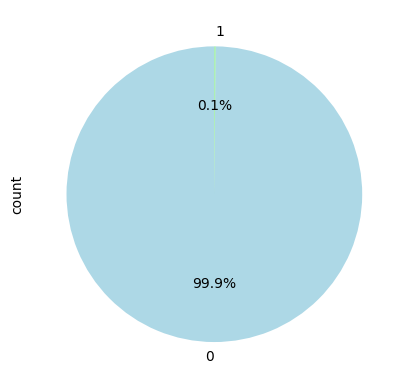

In [11]:
data['isFraud'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors = ['#add8e6', '#90ee90'])

(0.0, 5000000.0)

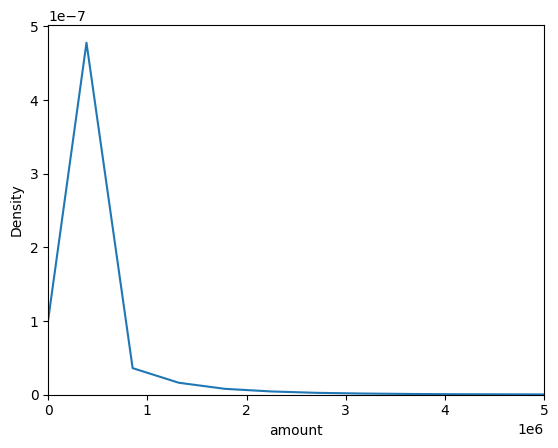

In [12]:
sns.kdeplot(data,x='amount')
plt.xlim(0,5000000)

In [13]:
data['type'].value_counts().sort_values(ascending=False)

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

<Axes: xlabel='type', ylabel='count'>

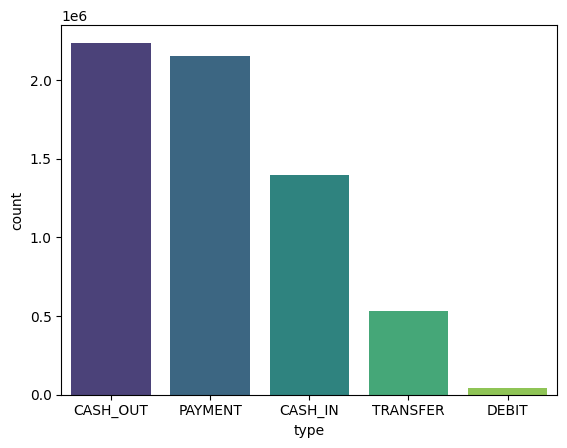

In [14]:
sns.countplot(data=data,x='type',palette='viridis',order=data["type"].value_counts().index)


Most transactions are Cash Out

In [16]:
data.groupby(['type', 'isFraud']).size().unstack()

isFraud,0,1
type,,
CASH_IN,1399284.0,NaN
CASH_OUT,2233384.0,4116.0
DEBIT,41432.0,NaN
PAYMENT,2151495.0,NaN
TRANSFER,528812.0,4097.0


<Axes: xlabel='type', ylabel='count'>

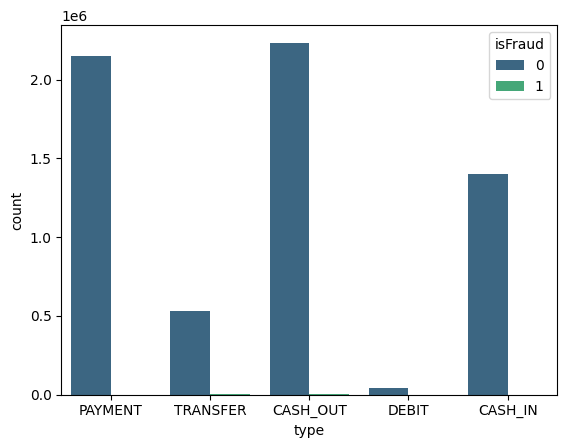

In [17]:
sns.countplot(data=data,x='type',hue='isFraud',palette='viridis')

<Axes: xlabel='type', ylabel='count'>

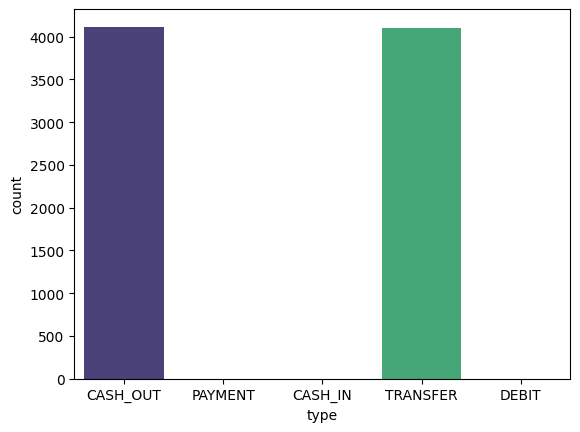

In [18]:
sns.countplot(data=data[data["isFraud"]==1],x='type',palette='viridis',order=data["type"].value_counts().index)

In [19]:
data.corr(numeric_only=True)['isFraud'].sort_values(ascending=False)

isFraud           1.000000
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64

<Axes: >

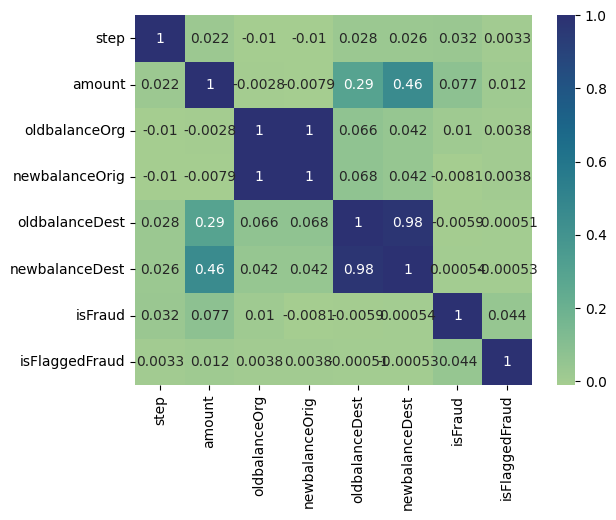

In [20]:
sns.heatmap(data.corr(numeric_only=True),cmap='crest',annot=True)

# Data Pre-Processing

In [21]:
print('Null Values:',data.isnull().sum())

Null Values: step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [22]:
print('Any duplicates samples?',data.duplicated().any())

Any duplicates samples? False


No null nor any duplicates.

In [23]:
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_lower = data[data[column] < lower_bound]
    outliers_upper= data[data[column] > upper_bound]
    return outliers_upper.shape[0],outliers_lower.shape[0]

In [24]:
outliers_upper_count,outliers_lower_count = detect_outliers(data, 'amount')
print(outliers_upper_count,outliers_lower_count)

338078 0


## Feature Engineering and Selection

In [26]:
data['transactionType'] = data['nameOrig'].str[0] + data['nameDest'].str[0]

In [27]:
data['net_sender'] = data['oldbalanceOrg'] - data['newbalanceOrig']
data['net_receiver'] = data['newbalanceDest'] - data['oldbalanceDest']

In [28]:
data[data['net_sender']<0].shape[0]

1399253

In [29]:
data=data.drop(['nameOrig','nameDest',"isFlaggedFraud"],axis=1)

In [30]:
data.corr(numeric_only=True)['isFraud'].sort_values(ascending=False)

isFraud           1.000000
net_sender        0.362472
amount            0.076688
step              0.031578
net_receiver      0.027028
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64

In [32]:
data=data.drop(['oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest'],axis=1)

In [33]:
data['transactionType'].unique()

array(['CM', 'CC'], dtype=object)

# Encoding

In [34]:
encoder = LabelEncoder()
data["type"] = encoder.fit_transform(data["type"])
data_onehot = pd.get_dummies(data, columns=['transactionType'], drop_first=True)
#or one hot

In [35]:
col=data_onehot.pop('isFraud')
data_onehot['isFraud']=col
data_onehot.head()

,step,type,amount,net_sender,net_receiver,transactionType_CM,isFraud
0,1,3,9839.64,9839.64,0.0,True,0
1,1,3,1864.28,1864.28,0.0,True,0
2,1,4,181.00,181.00,0.0,False,1
3,1,1,181.00,181.00,-21182.0,False,1
4,1,3,11668.14,11668.14,0.0,True,0


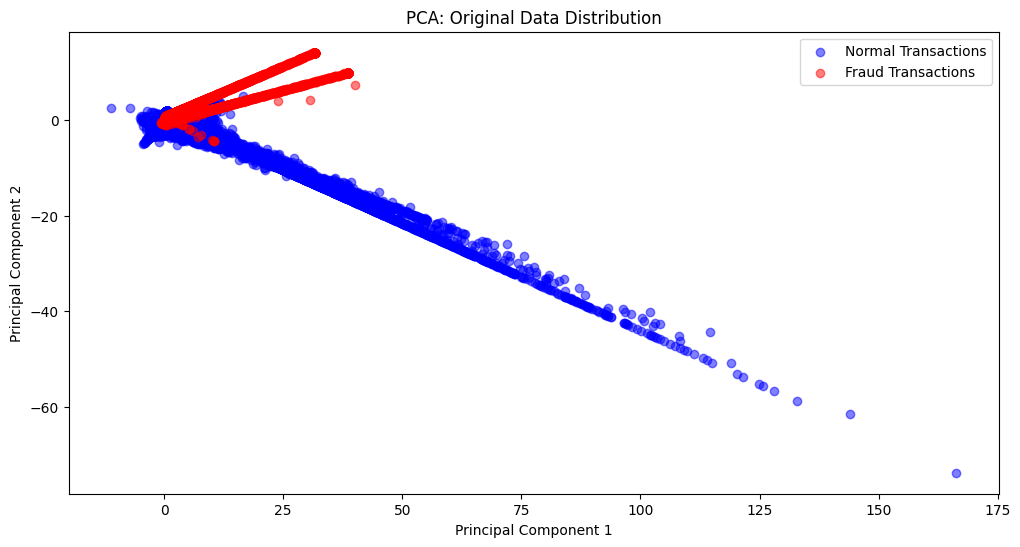

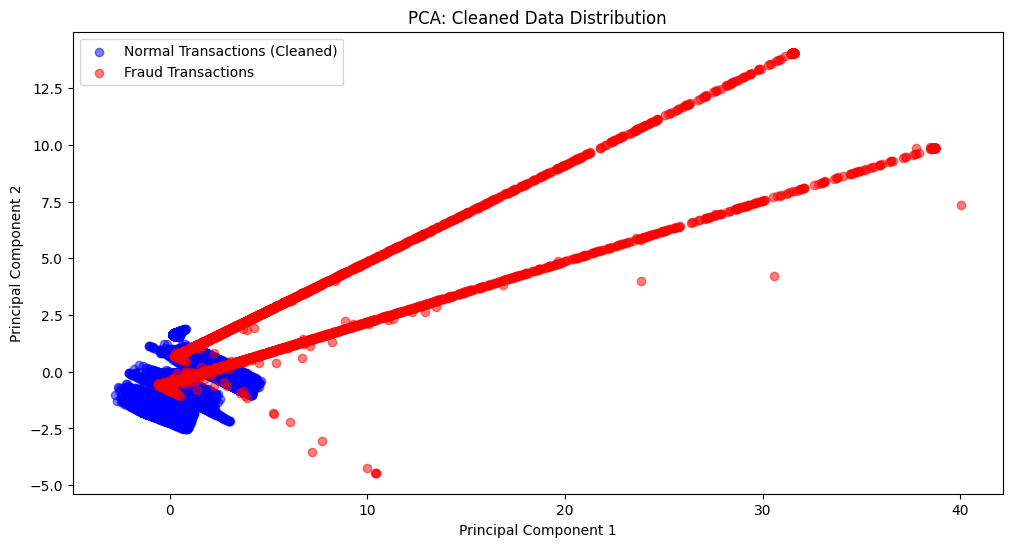

Original data shape: (6362620, 6)
Cleaned data shape: (6079707, 6)
Original normal transactions: 6354407
Cleaned normal transactions: 6071494
Removed outliers: 282913


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.stats import zscore

# 1. Data Preprocessing
# Separate features and labels
X = data_onehot.drop(columns=['isFraud'])  # Features
y = data_onehot['isFraud']  # Labels (0: normal transaction, 1: fraudulent transaction)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply PCA
pca = PCA(n_components=2)  # Reduce to 2D
X_pca = pca.fit_transform(X_scaled)

# 3. Visualize original data distribution
plt.figure(figsize=(12, 6))

# Normal transactions
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], color='blue', label='Normal Transactions', alpha=0.5)
# Fraudulent transactions
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], color='red', label='Fraud Transactions', alpha=0.5)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: Original Data Distribution')
plt.legend()
plt.show()

# 4. Remove outliers from normal transactions
# Extract normal transaction data
normal_data = X_scaled[y == 0]

# Use Z-Score to detect outliers
z_scores = np.abs(zscore(normal_data))  # Compute Z-Scores
threshold = 3  # Z-Score threshold
normal_data_cleaned = normal_data[(z_scores < threshold).all(axis=1)]  # Remove outliers

# Combine cleaned normal data with fraud data
X_cleaned = np.vstack((normal_data_cleaned, X_scaled[y == 1]))
y_cleaned = np.hstack((np.zeros(normal_data_cleaned.shape[0]), y[y == 1]))

# 5. Visualize cleaned data distribution
# Apply PCA to cleaned data
X_cleaned_pca = pca.transform(X_cleaned)

plt.figure(figsize=(12, 6))

# Cleaned normal transactions
plt.scatter(X_cleaned_pca[y_cleaned == 0, 0], X_cleaned_pca[y_cleaned == 0, 1], color='blue', label='Normal Transactions (Cleaned)', alpha=0.5)
# Fraudulent transactions
plt.scatter(X_cleaned_pca[y_cleaned == 1, 0], X_cleaned_pca[y_cleaned == 1, 1], color='red', label='Fraud Transactions', alpha=0.5)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: Cleaned Data Distribution')
plt.legend()
plt.show()

# 6. Verify cleaned data
print(f"Original data shape: {X_scaled.shape}")
print(f"Cleaned data shape: {X_cleaned.shape}")

original_normal_count = X_scaled[y == 0].shape[0]
cleaned_normal_count = X_cleaned[y_cleaned == 0].shape[0]
removed_outliers_count = original_normal_count - cleaned_normal_count

print(f"Original normal transactions: {original_normal_count}")
print(f"Cleaned normal transactions: {cleaned_normal_count}")
print(f"Removed outliers: {removed_outliers_count}")

# 7. Restore original scale
X_cleaned_original = scaler.inverse_transform(X_cleaned)

# Convert back to DataFrame
cleaned_data_original = pd.DataFrame(X_cleaned_original, columns=X.columns)
cleaned_data_original['isFraud'] = y_cleaned

# Save to CSV file
cleaned_data_original.to_csv("cleaned_data_original_scale.csv", index=False)


# Train Test Split

In [3]:
data_cleaned=pd.read_csv("cleaned_data_original_scale.csv")
data_cleaned.shape

(6079707, 7)

In [4]:
from sklearn.model_selection import train_test_split
# 1. Separate normal and fraudulent transaction data
normal_data = data_cleaned[data_cleaned["isFraud"] == 0]
fraud_data = data_cleaned[data_cleaned["isFraud"] == 1]

# 2. Split normal and fraud data separately
# Normal data
normal_train, normal_temp = train_test_split(normal_data, test_size=0.4, random_state=42)  # 60% training set
normal_val, normal_test = train_test_split(normal_temp, test_size=0.5, random_state=42)    # 20% validation set, 20% test set

# Fraudulent data
fraud_train, fraud_temp = train_test_split(fraud_data, test_size=0.4, random_state=42)     # 60% training set
fraud_val, fraud_test = train_test_split(fraud_temp, test_size=0.5, random_state=42)       # 20% validation set, 20% test set
# concat the validation and test data
val_data = pd.concat([normal_val, fraud_val])
test_data = pd.concat([normal_test, fraud_test])
train_data = pd.concat([normal_train, fraud_train])
# shuffle the order of data
val_data = val_data.sample(frac=1, random_state=42).reset_index(drop=True)
test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)
train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)
# split the target data and validation data of validation and test 
X_val = val_data.drop(columns=["isFraud"])
y_val = val_data["isFraud"]
X_test = test_data.drop(columns=["isFraud"])
y_test = test_data["isFraud"]
X_train = train_data.drop(columns=["isFraud"])
y_train = train_data["isFraud"]



In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [14]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_val_scaled=scaler.transform(X_val)

##### Preliminary Model Selection 

In [12]:
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.svm import SVC 
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier,GradientBoostingClassifier

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "SGD Classifier": SGDClassifier(n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    
}   
results= []    

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_model = model.predict(X_val_scaled)
    
    print(f"Classification Report for {name}:\n")
    print(classification_report(y_val, y_pred_model))

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred_model),
        'Precision': precision_score(y_val, y_pred_model),
        'Recall': recall_score(y_val, y_pred_model),
        'ROC-AUC': roc_auc_score(y_val, y_pred_model)
    })

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   1214299
         1.0       0.96      0.59      0.73      1643

    accuracy                           1.00   1215942
   macro avg       0.98      0.80      0.87   1215942
weighted avg       1.00      1.00      1.00   1215942

Classification Report for SGD Classifier:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   1214299
         1.0       0.94      0.62      0.74      1643

    accuracy                           1.00   1215942
   macro avg       0.97      0.81      0.87   1215942
weighted avg       1.00      1.00      1.00   1215942

Classification Report for Decision Tree:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   1214299
         1.0       0.85      0.85      0.85      1643

    accuracy                           1.00   121

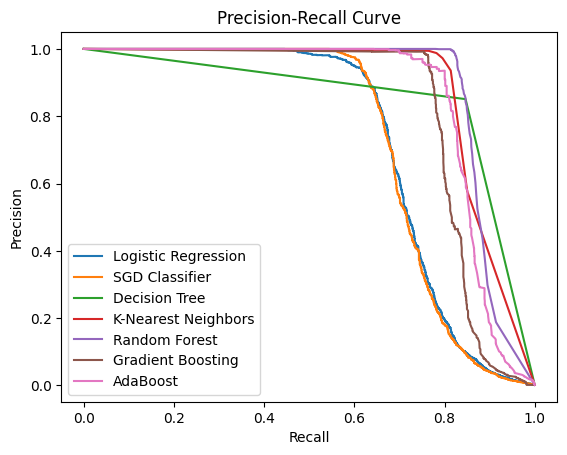

In [17]:
from sklearn.metrics import precision_recall_curve, roc_auc_score,roc_curve,auc
import numpy as np
import matplotlib.pyplot as plt 

for name, model in models.items():
    if isinstance(model, SGDClassifier) and model.loss == 'hinge':
        # Using decision_function()
        y_val_decision = model.decision_function(X_val_scaled)
        # Use decision_function() instead of predict_proba(), and modify the subsequent precision_recall_curve call
        precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_decision)
    else:
        # Using predict_proba()
        y_val_pro = model.predict_proba(X_val_scaled)[:, 1]  # positive result
        precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_pro)

    # Plot precision-recall curve
    plt.plot(recalls, precisions, label=name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

Define Validation Evaluation function

In [ ]:
from sklearn.metrics import precision_recall_curve
def validation_evaluate_model(model, X_val, y_val):
    # predication
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1] 

    # calculating metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred_proba)

    # result
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    # calculating Precision-Recall curve
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_proba)

    # draw curve
    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "r-", label="Recall")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Precision-Recall vs Threshold")
    plt.legend()
    plt.show()

    # draw ROC curve
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

    return accuracy, precision, recall, f1, roc_auc


Accuracy: 0.9997
Precision: 0.9875
Recall: 0.8198
F1 Score: 0.8959
ROC-AUC: 0.9525


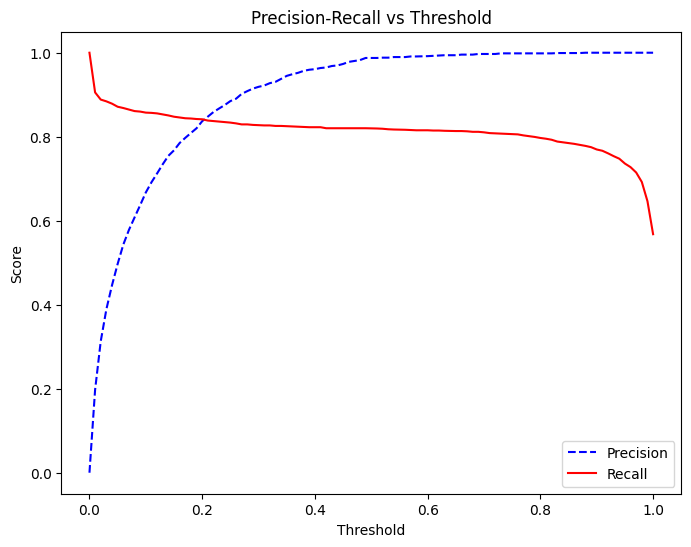

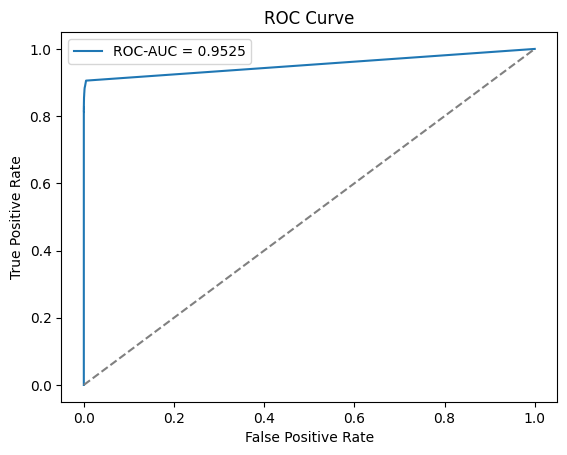

In [ ]:

# training RandomForest model
model = RandomForestClassifier(class_weight='balanced',random_state=42)
model.fit(X_train, y_train)

# evalutate model
accuracy, precision, recall, f1, roc_auc = validation_evaluate_model(model, X_val, y_val)


In [ ]:
# Get all parameters of the model
params = model.get_params()

# Print the list of parameters
for key, value in params.items():
    print(f"{key}: {value}")

bootstrap: True
ccp_alpha: 0.0
class_weight: balanced
criterion: gini
max_depth: None
max_features: sqrt
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 100
n_jobs: None
oob_score: False
random_state: 42
verbose: 0
warm_start: False


#### Model Optimization (Two-Stage Randomized Hyperparameter Search)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Accuracy: 0.9997
Precision: 0.9948
Recall: 0.8168
F1 Score: 0.8971
ROC-AUC: 0.9973


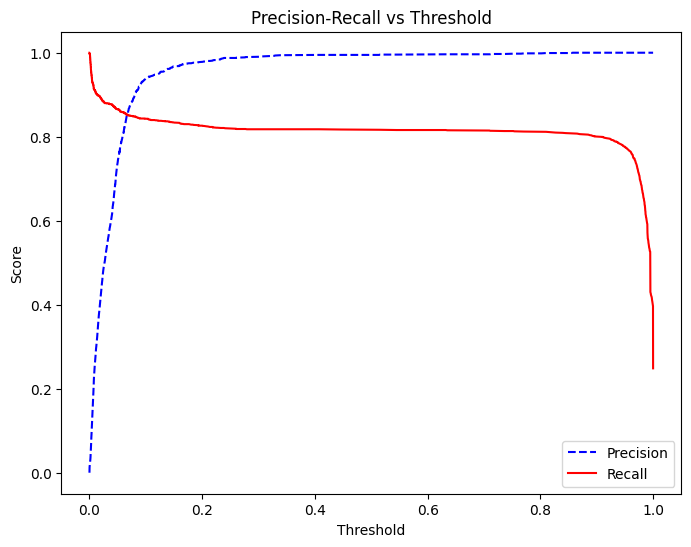

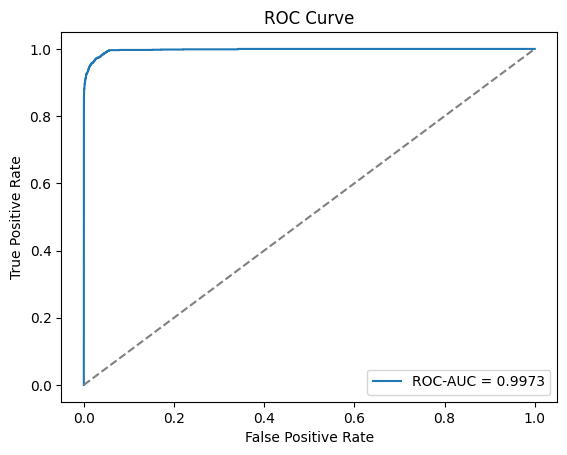


<< 第一阶段最佳参数 >>
{'class_weight': None, 'criterion': 'entropy', 'max_depth': 16, 'max_features': 'log2', 'min_samples_leaf': 3, 'n_estimators': 174}

<< 最终最佳参数 >>
{'ccp_alpha': 0.0, 'class_weight': None, 'max_depth': 14, 'max_features': 'log2', 'min_impurity_decrease': 0.0, 'min_samples_leaf': 3, 'n_estimators': 195}

Validation Metrics: Accuracy=0.9997, Precision=0.9948, Recall=0.8168, F1=0.8971, AUC=0.9973


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier

# Phase 1: Broad-range quick screening (focus on key parameters)
param_dist_wide = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(10, 30),
    'min_samples_leaf': randint(1, 10),
    'class_weight': [None, 'balanced', {'class0':1, 'class1':5}],  # Assume ~20% positive class
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['entropy']
}

rf_model = RandomForestClassifier(random_state=42, bootstrap=True, oob_score=False)

# Phase 1 search (quick screening)
random_search_wide = RandomizedSearchCV(
    rf_model, 
    param_distributions=param_dist_wide,
    n_iter=15,  # 15 iterations for wide-range exploration
    scoring='roc_auc',  # Use AUC in phase 1 to avoid threshold sensitivity
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)
random_search_wide.fit(X_train, y_train)

# Phase 2: Fine-tuning (narrow range based on phase 1 results)
best_wide = random_search_wide.best_params_

param_dist_narrow = {
    'n_estimators': randint(max(100, best_wide['n_estimators']-50), 
                    min(300, best_wide['n_estimators']+50)),
    'max_depth': randint(max(10, best_wide['max_depth']-5), 
                 min(30, best_wide['max_depth']+5)),
    'min_samples_leaf': randint(max(1, best_wide['min_samples_leaf']-3), 
                              min(10, best_wide['min_samples_leaf']+3)),
    'class_weight': [best_wide['class_weight']],  # Lock in best class weight from phase 1
    'max_features': [best_wide['max_features']],  # Lock in best max_features from phase 1
    'min_impurity_decrease': [0.0, 0.1, 0.2],    # Add secondary parameter
    'ccp_alpha': [0.0, 0.01]                     # Add secondary parameter
}

# Phase 2 search (fine-tuning)
random_search_narrow = RandomizedSearchCV(
    random_search_wide.best_estimator_,  # Start from the best model of phase 1
    param_distributions=param_dist_narrow,
    n_iter=10,  # 10 iterations for fine-tuning
    scoring='f1',  # Optimize for F1 in the final phase
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)
random_search_narrow.fit(X_train, y_train)

# Get the final best model
best_rf_model = random_search_narrow.best_estimator_

# Validation evaluation
accuracy, precision, recall, f1, roc_auc = validation_evaluate_model(best_rf_model, X_val, y_val)

# Output results
print("\n<< Best Parameters from Phase 1 >>")
print(random_search_wide.best_params_)
print("\n<< Final Best Parameters >>")
print(random_search_narrow.best_params_)
print(f"\nValidation Metrics: Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, AUC={roc_auc:.4f}")

#### Get Optimized hyperparameters

In [19]:
print(random_search_narrow.best_params_)

{'ccp_alpha': 0.0, 'class_weight': None, 'max_depth': 14, 'max_features': 'log2', 'min_impurity_decrease': 0.0, 'min_samples_leaf': 3, 'n_estimators': 195}


In [ ]:

# using hyperparameters from above
best_rf_model = RandomForestClassifier(
    n_estimators=195,
    max_depth=14,
    max_features='log2',
    min_samples_leaf=3,
    ccp_alpha=0.0,
    class_weight=None,
    min_impurity_decrease=0.0,
    random_state=42,
    n_jobs=-1
)

# training model
best_rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=14, max_features='log2', min_samples_leaf=3,
                       n_estimators=195, n_jobs=-1, random_state=42)

In [ ]:
# Calculate the 25th and 75th percentiles
q25 = data_cleaned['amount'].quantile(0.25)
q75 = data_cleaned['amount'].quantile(0.75)

# Define amount intervals
amount_bins = [0, q25, q75, np.inf]
amount_labels = ['low', 'medium', 'high']

print(f"25%: {q25}, 75%: {q75}")

25%: 12730.869999999966, 75%: 192052.51


In [ ]:
# Assume the validation set has been split into X_val and y_val, and X_val contains the 'amount' column
# Define amount thresholds
usual_mask = X_val['amount'] <= q75
high_mask = X_val['amount'] > q75

# Split the validation set
X_val_usual, y_val_usual = X_val[usual_mask], y_val[usual_mask]
X_val_high, y_val_high = X_val[high_mask], y_val[high_mask]

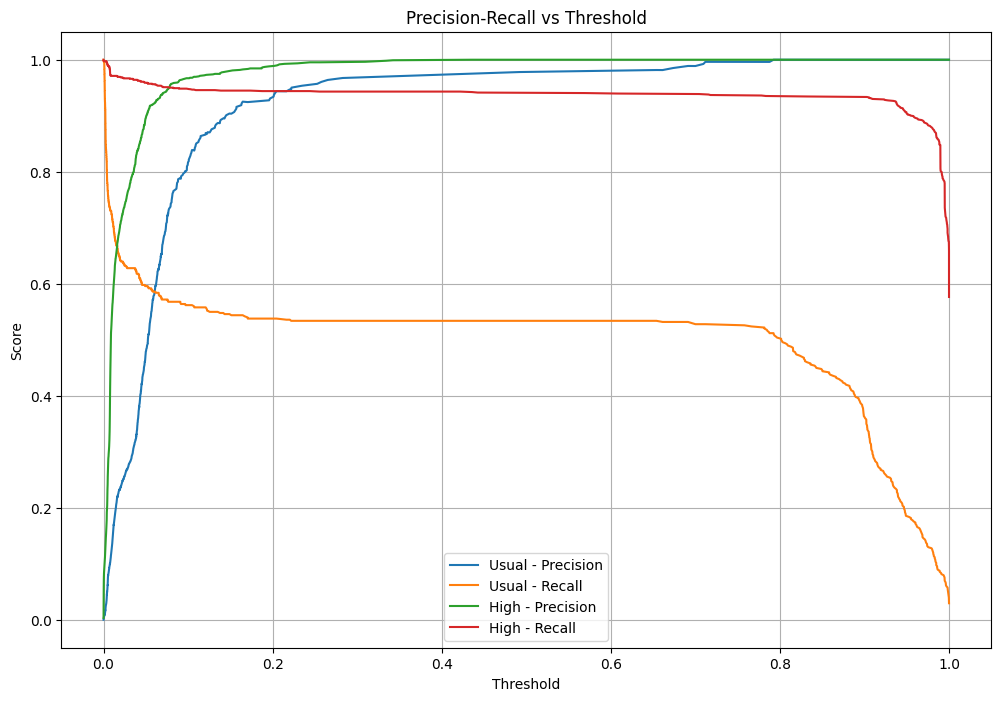

In [ ]:
from sklearn.metrics import precision_recall_curve
# Define a function to plot the recall-precision-threshold curve
def plot_precision_recall_vs_threshold(y_true, y_pred_proba, label):
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)
    plt.plot(thresholds, precision[:-1], label=f'{label} - Precision')
    plt.plot(thresholds, recall[:-1], label=f'{label} - Recall')

# Plot the curves
plt.figure(figsize=(12, 8))

# Usual transaction amount range
y_pred_proba_usual = best_rf_model.predict_proba(X_val_usual)[:, 1]
plot_precision_recall_vs_threshold(y_val_usual, y_pred_proba_usual, label='Usual')

# High transaction amount range
y_pred_proba_high = best_rf_model.predict_proba(X_val_high)[:, 1]
plot_precision_recall_vs_threshold(y_val_high, y_pred_proba_high, label='High')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid()
plt.show()

In [ ]:
def find_threshold_by_recall(y_true, y_pred_proba, target_recall):
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)
    # Find the threshold closest to the target recall
    idx = np.argmin(np.abs(recall - target_recall))
    return thresholds[idx]

In [ ]:
# High amount range: threshold for recall = 0.98
y_pred_proba_high = best_rf_model.predict_proba(X_val_high)[:, 1]
threshold_high = find_threshold_by_recall(y_val_high, y_pred_proba_high, target_recall=0.98)

# Print the result
print(f"the high financial threshold of Precision and Recall(recall=0.98): {threshold_high}")

the high finacial threshold of Precision and Recall(recall=0.98): 0.007643938989508205


#### split the test data accroding to the transaction amount  
1,seting the the amount above 75% as High risk transction in order to decrease missed detections(False negative)  
2,seting the the amount below 75% as usual transction for decrease false alarm

##### real-time detection model

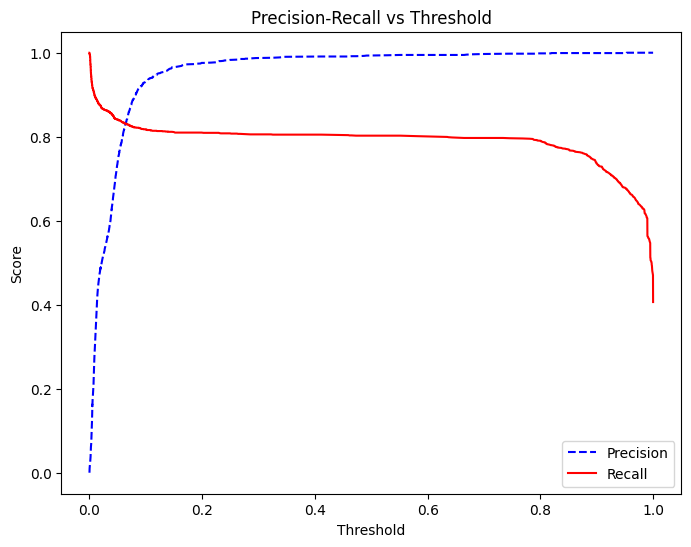

High Amount Performance:
Precision: 0.3789, Recall: 0.9837, F1 Score: 0.5471,AUC=0.9889
Usual Amount Performance:
Precision: 0.9791, Recall: 0.5213, F1 Score: 0.6804,AUC=0.7607

Final Model Performance:
Precision: 0.9940, Recall: 0.8028, F1 Score: 0.8882, AUC=0.9014


In [ ]:
# Calculate Q1
q1 = data_cleaned['amount'].quantile(0.75)

# Get probability predictions
y_test_probs = best_rf_model.predict_proba(X_test)[:, 1]
# Calculate Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_probs)

# Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "r-", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.show()

# Define conditions and corresponding thresholds
conditions = [
    (X_test['amount'] > q1),  # High amount range
    (X_test['amount'] < q1),  # Normal amount range
]
choices = [threshold_high, 0.5]

# Select threshold based on conditions
thresholds = np.select(conditions, choices, default=0.5)

# Predict based on thresholds
y_test_pred = (y_test_probs >= thresholds).astype(int)

# Split into amount ranges
high_amount_mask = X_test['amount'] > q1  # High amount range
usual_amount_mask = X_test['amount'] < q1  # Normal amount range

# Define evaluation function
def evaluate_performance(y_true, y_pred, label):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred)
    print(f"{label} Performance:")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}, AUC={roc_auc:.4f}")

# High amount range evaluation
evaluate_performance(y_test[high_amount_mask], y_test_pred[high_amount_mask], "High Amount")

# Normal amount range evaluation
evaluate_performance(y_test[usual_amount_mask], y_test_pred[usual_amount_mask], "Usual Amount")

# Assuming y_test_probs are anomaly scores (higher values indicate more likely anomaly)
threshold = 0.5  # Adjust threshold based on business or validation set
y_pred_binary = (y_test_probs > threshold).astype(int)

# Overall evaluation (optional)
final_precision = precision_score(y_test, y_pred_binary)
final_recall = recall_score(y_test, y_pred_binary)
final_f1 = f1_score(y_test, y_pred_binary)
final_roc_auc = roc_auc_score(y_test, y_pred_binary)

print(f"\nFinal Model Performance:")
print(f"Precision: {final_precision:.4f}, Recall: {final_recall:.4f}, F1 Score: {final_f1:.4f}, AUC={final_

#### The end